# Bare-metal node health -- are lancer & acebase happy?

Reads the **actual hardware and OS values** off the two bare-metal Talos workers and judges
whether each box is healthy -- not merely whether telemetry is arriving. Both are ordinary
Kubernetes nodes scraped in-cluster (`cluster="tiles"`), so unlike the Proxmox LXC edge feed
the values here are **genuine host values** (real node_exporter, real memory -- no cgroup caveat).

- **lancer** -- AMD APU (Ryzen, `k10temp` CPU + `amdgpu` iGPU), 32 threads, 64 GiB, NVMe.
- **acebase** -- Intel Alder Lake-N (`coretemp`), 4 threads, 8 GiB, SATA SSD (GNSS RTK base, [tiles#547](https://github.com/symmatree/tiles/issues/547)).

Motivated by what actually makes one of these unhappy (a hot day, a power event, a runaway pod):
- **Thermal**: CPU/iGPU/storage overheating or thermal throttling.
- **Storage**: the Talos `/var` state partition filling, or an SSD running hot.
- **Resources**: CPU saturation, memory pressure, load vs cores, disk I/O saturation.
- **Cluster membership**: the node `NotReady`, under a kubelet pressure condition, or -- the
  distinctive metal failure mode -- a stray `talos-<rand>` duplicate Node after a DHCP-less boot
  ([#641](https://github.com/symmatree/tiles/issues/641), [bare-metal-nodes.md](../docs/bare-metal-nodes.md#node-hostnames-and-dhcp-less-boot)).

**"Is the node even delivering?"** is *not* a separate notebook -- it is one **assumptions gate**
here: if a node's metrics are stale we cannot assess it and say so. Design correction per
[#653](https://github.com/symmatree/tiles/issues/653): read the values, do not split ingestion off.

**Thresholds are sourced, not invented.** Temperature thresholds come from the deployed
**bond-mixin** metal alerts (`BondMetalHighCpuTemperature` 90 C, `BondMetalHighGpuTemperature`
95 C; [#687](https://github.com/symmatree/tiles/issues/687)); CPU/memory/filesystem/load/disk
thresholds from the deployed **node-exporter mixin** (`NodeCPUHighUsage` 90%,
`NodeMemoryHighUtilization` 90%, `NodeSystemSaturation` 2/core, `NodeFilesystemAlmostOutOfSpace`
5%/3% avail, `NodeDiskIOSaturation` 10). Each finding names its source. Live `ALERTS` state is
read as a cross-check.

Design: [tiles#653](https://github.com/symmatree/tiles/issues/653) (parent
[#644](https://github.com/symmatree/tiles/issues/644)), [docs/notebooks.md](../docs/notebooks.md),
sibling `proxmox-health.ipynb` and `raconteur-health.ipynb`.

Run from `notebooks/`: `jupyter nbconvert --to notebook --execute --inplace metal-health.ipynb`

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"   # node_exporter + kube_state land in Mimir
loki_url = "http://loki.loki.svc:3100"        # Talos host logs (integrations/talos)
tenant = "tiles"                # X-Scope-OrgID (also the k8s cluster these nodes belong to)
cluster = "tiles"               # node_exporter cluster label for the metal workers
instance_re = "lancer|acebase"  # node_exporter/instance selector
expected_nodes = ["lancer", "acebase"]  # enumerate so a missing node is a finding, not a blank row
reserved_ips = {"lancer": "10.0.128.51", "acebase": "10.0.99.14"}  # UniFi fixed-IP reservations (bare-metal-nodes.md)
lookback_hours = 24
range_step_s = 300
metric_stale_s = 900       # chosen (no mixin): node_exporter is a fixed-interval scrape; staler = unassessable
instr_stale_s = 600        # chosen: Mimir-serving freshness gate
cpu_temp_warn_c = 90       # sourced: bond-mixin BondMetalHighCpuTemperature (k10temp/coretemp, 10m)
gpu_temp_warn_c = 95       # sourced: bond-mixin BondMetalHighGpuTemperature (amdgpu, 10m)
storage_temp_warn_c = 70   # chosen: NVMe/SATA warn below the hardware crit (read live for headroom)
cpu_busy_warn_pct = 90     # sourced: node-exporter mixin NodeCPUHighUsage
mem_used_warn_pct = 90     # sourced: node-exporter mixin NodeMemoryHighUtilization
load_per_core_warn = 2     # sourced: node-exporter mixin NodeSystemSaturation
fs_full_warn_pct = 95      # sourced: NodeFilesystemAlmostOutOfSpace (avail < 5%)
fs_full_crit_pct = 97      # sourced: NodeFilesystemAlmostOutOfSpace critical (avail < 3%)
disk_io_sat_warn = 10      # sourced: node-exporter mixin NodeDiskIOSaturation (io_time_weighted rate)
psi_some_warn_pct = 20     # chosen: PSI "some stalled" fraction over 5m worth a look (genuine here)
capture_file = ""          # replay a prior raw capture JSON instead of querying live
output_dir = ""            # if set: write raw capture + agent stats there
debug = False

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'metal-health'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, loki_url=loki_url, tenant=tenant,
                  cluster=cluster, instance_re=instance_re, expected_nodes=expected_nodes,
                  reserved_ips=reserved_ips, lookback_hours=lookback_hours, range_step_s=range_step_s,
                  metric_stale_s=metric_stale_s)
m = cap.meta
tenant, cluster, instance_re = m['tenant'], m['cluster'], m['instance_re']
expected_nodes, reserved_ips = m['expected_nodes'], m['reserved_ips']
lookback_hours, step, metric_stale_s = m['lookback_hours'], m['range_step_s'], m['metric_stale_s']
mm = nbc.Mimir(cap, m['mimir_url'], tenant)
lk = nbc.Loki(cap, m['loki_url'], tenant)
kube = nbc.Kube(cap)
SEL = f'cluster="{cluster}", instance=~"{instance_re}"'   # node_exporter selector for the metal nodes


def byi(res):
    """{instance: value} from an instant vector keyed by the instance label."""
    return {r['metric'].get('instance', ''): float(r['value'][1]) for r in res}

print(f"mimir: {m['mimir_url']}  loki: {m['loki_url']}  tenant: {tenant}  nodes: {expected_nodes}  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  loki: http://loki.loki.svc:3100  tenant: tiles  nodes: ['lancer', 'acebase']  live


In [3]:
# --- ASSUMPTIONS: instruments before readings (the one data-through gate) ---
# 1) Mimir is serving fresh data at all; 2) each expected node is present and fresh. A node that
# is stale/missing is UNASSESSABLE (we cannot read its values) -- if ALL are gone we stop; the
# likely cause for a single metal node is a talos-<rand> DHCP-less boot (#641), checked below.
mimir_ts = nbc.val(mm.q('instr: mimir up', 'max(timestamp(up))'))
mimir_age = cap.now - mimir_ts if not np.isnan(mimir_ts) else np.inf

node_ts = byi(mm.q('fresh: node_load1 by node', f'timestamp(node_load1{{{SEL}}})'))
node_age = {n: (cap.now - node_ts[n] if n in node_ts else np.inf) for n in expected_nodes}
present = [n for n in expected_nodes if node_age[n] <= metric_stale_s]
stale = [n for n in expected_nodes if n not in present]

# Cluster membership cross-check (kube_state metrics in Mimir) + the talos-<rand> duplicate gate.
ready = {r['metric'].get('node', ''): float(r['value'][1])
         for r in mm.q('kube: ready', f'kube_node_status_condition{{node=~"{instance_re}", condition="Ready", status="true"}}')}
talos_rand = mm.q('kube: talos-rand', 'kube_node_info{node=~"talos-.*"}')  # empty = no DHCP-less duplicate

print("=== ASSUMPTIONS (data-through gate) ===")
print(f"  mimir serving (up)   {'MISSING' if np.isinf(mimir_age) else f'{mimir_age:.0f}s old'}")
for n in expected_nodes:
    a = node_age[n]
    rd = 'Ready' if ready.get(n) == 1 else ('NOT Ready' if n in ready else 'no kube_node')
    print(f"  {n:<10} node_exporter {'MISSING' if np.isinf(a) else f'{a:.0f}s old':<12} kube: {rd}")
if np.isinf(mimir_age) or mimir_age > instr_stale_s:
    raise RuntimeError(f"unassessable: Mimir not serving fresh data ({mimir_age:.0f}s) -- see mimir-health.ipynb")
if not present:
    raise RuntimeError(f"unassessable: NONE of {expected_nodes} are delivering fresh metrics "
                       f"(all > {metric_stale_s}s). Suspect a node-down or DHCP-less boot -- check for a "
                       f"talos-<rand> duplicate Node (#641, bare-metal-nodes.md) and kubectl get nodes.")
for n in stale:
    print(f"  WARNING: {n} stale/missing (> {metric_stale_s}s) -- rendered as UNASSESSABLE below, not healthy")
if talos_rand:
    names = ", ".join(f"{r['metric'].get('node','?')}({r['metric'].get('internal_ip','?')})" for r in talos_rand)
    print(f"  !! STRAY talos-<rand> Node object(s) present: {names} -- DHCP-less boot (#641); "
          f"the real node may be NotReady sharing that IP. Reboot the node, then delete the stray.")
else:
    print(f"  talos-<rand> duplicate check: clean (no stray Node objects)")
present_sel = f'cluster="{cluster}", instance=~"{"|".join(present)}"'  # only assessable nodes below

=== ASSUMPTIONS (data-through gate) ===
  mimir serving (up)   1s old
  lancer     node_exporter 47s old      kube: Ready
  acebase    node_exporter 14s old      kube: Ready
  talos-<rand> duplicate check: clean (no stray Node objects)


In [4]:
# --- CAPTURE: the complete raw observation up front (analysis below is a pure function of this) ---
S = present_sel
JOIN = 'on(instance,chip) group_left(chip_name) node_hwmon_chip_names'

# Temperatures (chip_name join handles heterogeneous chips: k10temp vs coretemp, amdgpu, nvme/drivetemp)
cpu_temp = byi(mm.q('cpu_temp', f'max by(instance)(node_hwmon_temp_celsius{{{S}}} * {JOIN}{{chip_name=~"k10temp|coretemp"}})'))
gpu_temp = byi(mm.q('gpu_temp', f'max by(instance)(node_hwmon_temp_celsius{{{S}}} * {JOIN}{{chip_name=~"amdgpu"}})'))
stor_temp = byi(mm.q('stor_temp', f'max by(instance)(node_hwmon_temp_celsius{{{S}}} * {JOIN}{{chip_name=~"nvme|drivetemp"}})'))
# hardware-reported crit (context/headroom); nvme composite temp2/3 report bogus max, so crit only
cpu_crit = byi(mm.q('cpu_crit', f'max by(instance)(node_hwmon_temp_crit_celsius{{{S}}} * {JOIN}{{chip_name=~"k10temp|coretemp"}})'))
stor_crit = byi(mm.q('stor_crit', f'max by(instance)(node_hwmon_temp_crit_celsius{{{S}}} * {JOIN}{{chip_name=~"nvme|drivetemp"}})'))
power_w = byi(mm.q('power_w', f'sum by(instance)(node_hwmon_power_watt{{{S}}})'))

# Throttle response: Processor / intel_powerclamp cooling devices (not PCIe/Fan step devices).
# cur == 0 => not throttling.
cool_cur = byi(mm.q('cool_cur', f'max by(instance)(node_cooling_device_cur_state{{{S}, type=~"Processor|intel_powerclamp"}})'))
cool_max = byi(mm.q('cool_max', f'max by(instance)(node_cooling_device_max_state{{{S}, type=~"Processor|intel_powerclamp"}})'))

# Resources (GENUINE host values here). CPU busy per node-exporter mixin NodeCPUHighUsage expr.
cpu_busy = byi(mm.q('cpu_busy', f'sum by(instance)(avg without(cpu)(rate(node_cpu_seconds_total{{{S}, mode!~"idle|iowait"}}[5m]))) * 100'))
ncpu = byi(mm.q('ncpu', f'count by(instance)(count by(instance,cpu)(node_cpu_seconds_total{{{S}, mode="idle"}}))'))
load1 = byi(mm.q('load1', f'node_load1{{{S}}}'))
mem_total = byi(mm.q('mem_total', f'node_memory_MemTotal_bytes{{{S}}}'))
mem_used_pct = byi(mm.q('mem_used_pct', f'100 - (node_memory_MemAvailable_bytes{{{S}}} / node_memory_MemTotal_bytes{{{S}}} * 100)'))
boot = byi(mm.q('boot', f'node_boot_time_seconds{{{S}}}'))

# Pressure (PSI, genuine): fraction of the last 5m some/any task stalled.
psi_cpu = byi(mm.q('psi_cpu', f'rate(node_pressure_cpu_waiting_seconds_total{{{S}}}[5m])'))
psi_io = byi(mm.q('psi_io', f'rate(node_pressure_io_waiting_seconds_total{{{S}}}[5m])'))
psi_mem = byi(mm.q('psi_mem', f'rate(node_pressure_memory_waiting_seconds_total{{{S}}}[5m])'))
disk_io_sat = byi(mm.q('disk_io_sat', f'max by(instance)(rate(node_disk_io_time_weighted_seconds_total{{{S}}}[5m]))'))

# Filesystem fullness -- Talos exposes the writable /var state partition (image/container storage).
fs_avail = mm.q('fs_avail', f'node_filesystem_avail_bytes{{{S}, fstype=~"ext4|xfs|btrfs"}}')
fs_size = mm.q('fs_size', f'node_filesystem_size_bytes{{{S}, fstype=~"ext4|xfs|btrfs"}}')

# Kube conditions (pressure flags) + node info
cond = mm.q('kube_cond', f'kube_node_status_condition{{node=~"{instance_re}", condition=~"MemoryPressure|DiskPressure|PIDPressure", status="true"}}')
kube_nodes = kube.get('kubectl_nodes', 'nodes')  # live cross-check incl. any talos-<rand>

# Live alert state (cross-check; empty = nothing firing/pending)
alerts = mm.q('alerts', 'ALERTS{alertname=~"BondMetal.*|NodeFilesystem.*|NodeCPUHighUsage|NodeSystemSaturation|'
                        'NodeMemoryHighUtilization|NodeDiskIOSaturation|NodeSystemdServiceFailed|NodeClockNotSynchronising", '
                        'alertstate=~"firing|pending"}')

# Trends
f_cputemp = nbc.frame(mm.qr('cputemp_trend', f'max by(instance)(node_hwmon_temp_celsius{{{S}}} * {JOIN}{{chip_name=~"k10temp|coretemp"}})', lookback_hours, step), 'instance')
f_gputemp = nbc.frame(mm.qr('gputemp_trend', f'max by(instance)(node_hwmon_temp_celsius{{{S}}} * {JOIN}{{chip_name=~"amdgpu"}})', lookback_hours, step), 'instance')
f_cpubusy = nbc.frame(mm.qr('cpubusy_trend', f'sum by(instance)(avg without(cpu)(rate(node_cpu_seconds_total{{{S}, mode!~"idle|iowait"}}[5m]))) * 100', lookback_hours, step), 'instance')

# Wide-angle log tail (proves collection is alive; catches what the curated queries filtered out)
log_bad = lk.lines('logs_warn_error', f'{{job="integrations/talos", instance=~"{instance_re}"}} | detected_level=~"error|warn"', lookback_hours, 60)
log_tail = lk.lines('logs_tail', f'{{job="integrations/talos", instance=~"{instance_re}"}}', 6, 40)
print(f"captured {len(cap.data['calls'])} raw calls; assessable nodes: {present}; "
      f"{len(log_bad)} warn/error log lines in {lookback_hours}h")

captured 32 raw calls; assessable nodes: ['lancer', 'acebase']; 60 warn/error log lines in 24h


In [5]:
# --- PER-NODE HEALTH TABLE (the deliverable: one row per node, judged) ---
def g(d, n):
    v = d.get(n)
    return float('nan') if v is None else v

rows = []
for n in expected_nodes:
    if n not in present:
        rows.append({'node': n, 'state': 'UNASSESSABLE (stale/missing)'}); continue
    up_d = (cap.now - boot[n]) / 86400 if n in boot else float('nan')
    rows.append({
        'node': n, 'state': 'Ready' if ready.get(n) == 1 else 'NOT Ready',
        'up_d': up_d,
        'cpuC': g(cpu_temp, n), 'gpuC': g(gpu_temp, n), 'stoC': g(stor_temp, n),
        'cpu%': g(cpu_busy, n), 'load/c': (load1[n]/ncpu[n] if ncpu.get(n) else float('nan')),
        'mem%': g(mem_used_pct, n), 'memGi': g(mem_total, n)/2**30 if n in mem_total else float('nan'),
        'ioSat': g(disk_io_sat, n), 'PSIio%': 100*g(psi_io, n), 'throttle': int(g(cool_cur, n)) if not np.isnan(g(cool_cur, n)) else 0,
        'W': g(power_w, n),
    })
tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False, na_rep='-', float_format=lambda v: f'{v:.1f}'))
print("\ncpuC/gpuC/stoC = hottest CPU/iGPU/storage sensor C  |  cpu% busy (non-idle,non-iowait, 5m)  |  "
      "load/c = load1 per core  |  ioSat = weighted disk-io rate  |  PSIio% = time stalled on I/O (5m)  |  "
      "throttle = cooling cur_state (0=none)  |  W = package power (amdgpu, where reported)")

   node state  up_d  cpuC  gpuC  stoC  cpu%  load/c  mem%  memGi  ioSat  PSIio%  throttle    W
 lancer Ready   8.6  37.6  36.0  36.9   1.4     0.0  10.6   62.3    0.0     0.2         0 11.1
acebase Ready   8.6  37.0     -  41.0   6.2     0.1  24.6    7.5    0.0     0.5         0    -

cpuC/gpuC/stoC = hottest CPU/iGPU/storage sensor C  |  cpu% busy (non-idle,non-iowait, 5m)  |  load/c = load1 per core  |  ioSat = weighted disk-io rate  |  PSIio% = time stalled on I/O (5m)  |  throttle = cooling cur_state (0=none)  |  W = package power (amdgpu, where reported)


lancer: CPU 38C (warn 90)  iGPU 36C (warn 95)  storage 37C (hw crit 95C)
acebase: CPU 37C (warn 90, hw crit 105C)  iGPU n/a  storage 41C


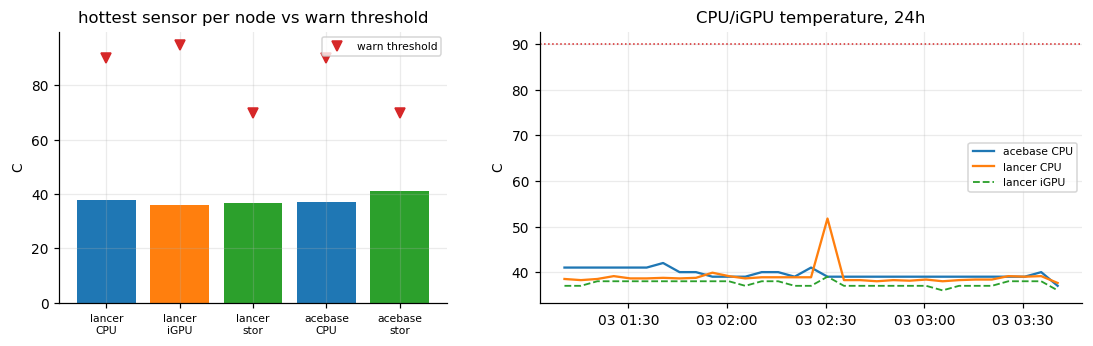

In [6]:
# --- TEMPERATURES: hottest sensor per node vs the deployed alert thresholds (+ hardware crit headroom) ---
# CPU 90 C (BondMetalHighCpuTemperature), iGPU 95 C (BondMetalHighGpuTemperature); storage vs its
# hardware-reported crit. Everything cool today is the expected baseline -- this section earns its
# keep on a hot day / under sustained ROCm-or-build load, and as the before/after around a power event.
for n in present:
    cc = cpu_crit.get(n); sc = stor_crit.get(n)
    ccs = f", hw crit {cc:.0f}C" if cc is not None else ""       # k10temp (lancer) reports no crit
    print(f"{n}: CPU {cpu_temp.get(n, float('nan')):.0f}C (warn {cpu_temp_warn_c}{ccs})"
          + (f"  iGPU {gpu_temp[n]:.0f}C (warn {gpu_temp_warn_c})" if n in gpu_temp else "  iGPU n/a")
          + (f"  storage {stor_temp[n]:.0f}C" + (f" (hw crit {sc:.0f}C)" if sc is not None else "") if n in stor_temp else ""))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), width_ratios=[1, 1.4])
ax = axes[0]
labels, vals, cols, thr = [], [], [], []
for n in present:
    for k, d, t, c in [('CPU', cpu_temp, cpu_temp_warn_c, 'C0'), ('iGPU', gpu_temp, gpu_temp_warn_c, 'C1'), ('stor', stor_temp, storage_temp_warn_c, 'C2')]:
        if n in d:
            labels.append(f'{n}\n{k}'); vals.append(d[n]); thr.append(t)
            cols.append('C3' if d[n] >= t else c)
ax.bar(range(len(vals)), vals, color=cols)
ax.plot(range(len(vals)), thr, 'v', color='C3', ms=7, label='warn threshold')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel('C'); ax.set_title('hottest sensor per node vs warn threshold'); ax.legend(fontsize=7)
ax = axes[1]
for n in [c for c in f_cputemp.columns]:
    ax.plot(f_cputemp.index, f_cputemp[n], lw=1.5, label=f'{n} CPU')
for n in [c for c in f_gputemp.columns]:
    ax.plot(f_gputemp.index, f_gputemp[n], lw=1.2, ls='--', label=f'{n} iGPU')
ax.axhline(cpu_temp_warn_c, color='C3', ls=':', lw=1)
ax.set_ylabel('C'); ax.set_title(f'CPU/iGPU temperature, {lookback_hours}h'); ax.legend(fontsize=7)
nbc.show(fig)

In [7]:
# --- RESOURCES, PRESSURE & CLUSTER MEMBERSHIP ---
# Genuine host values (real node_exporter): CPU busy, memory, load/core, PSI, disk-io saturation.
print("resources (genuine host values):")
for n in present:
    nc = ncpu.get(n) or float('nan')
    print(f"  {n}: cpu {cpu_busy.get(n, float('nan')):.0f}% busy / {int(nc) if nc == nc else '?'} cores"
          f"  load1 {load1.get(n, float('nan')):.2f} ({load1.get(n, 0) / nc:.2f}/core)"
          f"  mem {mem_used_pct.get(n, float('nan')):.0f}% of {mem_total.get(n, 0) / 2**30:.0f}GiB"
          f"  PSI cpu/io/mem {100*psi_cpu.get(n, 0):.1f}/{100*psi_io.get(n, 0):.1f}/{100*psi_mem.get(n, 0):.1f}%"
          f"  ioSat {disk_io_sat.get(n, float('nan')):.2f} (warn {disk_io_sat_warn})")

# Filesystem fullness (/var etc.)
av = {(r['metric'].get('instance',''), r['metric'].get('mountpoint','')): float(r['value'][1]) for r in fs_avail}
sz = {(r['metric'].get('instance',''), r['metric'].get('mountpoint','')): float(r['value'][1]) for r in fs_size}
vol_full = {k: 100*(1 - av[k]/sz[k]) for k in sz if sz[k] > 0}
print("\nfilesystem fullness (Talos writable partitions):")
for (n, mp), pct in sorted(vol_full.items()):
    print(f"  {n:<8} {mp:<8} {pct:5.1f}% full ({av[(n,mp)]/2**30:.0f}GiB free of {sz[(n,mp)]/2**30:.0f}GiB)")

# Kube pressure conditions + throttle
under_pressure = [(r['metric'].get('node',''), r['metric'].get('condition','')) for r in cond if float(r['value'][1]) == 1]
print(f"\nkube pressure conditions asserted: {under_pressure or 'none'}")
throttling = [n for n in present if cool_cur.get(n, 0) > 0]
print(f"active thermal throttle (cooling cur_state>0): {throttling or 'none'}")
kn = {i['metadata']['name']: i for i in kube_nodes.get('items', [])}
strays = [name for name in kn if name.startswith('talos-')]
print(f"kubectl nodes: {len(kn)} total; metal Ready: "
      + ", ".join(f"{n}={'Ready' if any(c['type']=='Ready' and c['status']=='True' for c in kn[n]['status']['conditions']) else 'NotReady'}" for n in expected_nodes if n in kn)
      + (f"  !! STRAY: {strays}" if strays else "  (no talos-<rand> strays)"))

resources (genuine host values):
  lancer: cpu 1% busy / 32 cores  load1 0.16 (0.01/core)  mem 11% of 62GiB  PSI cpu/io/mem 0.2/0.2/0.0%  ioSat 0.03 (warn 10)
  acebase: cpu 6% busy / 4 cores  load1 0.32 (0.08/core)  mem 25% of 7GiB  PSI cpu/io/mem 0.7/0.5/0.0%  ioSat 0.01 (warn 10)

filesystem fullness (Talos writable partitions):
  acebase  /var      10.2% full (212GiB free of 236GiB)
  lancer   /var       6.0% full (1748GiB free of 1860GiB)

kube pressure conditions asserted: none
active thermal throttle (cooling cur_state>0): none
kubectl nodes: 8 total; metal Ready: lancer=Ready, acebase=Ready  (no talos-<rand> strays)


In [8]:
# --- TALOS HOST LOGS: recent warn/error, plus a raw tail (proves logs flow, catches the uncurated) ---
# integrations/talos logs ARE collected for metal (unlike Proxmox hosts, #686). detected_level is
# structured metadata -- filtered as a pipeline stage.
print(f"warn/error lines in the last {lookback_hours}h: {len(log_bad)}")
for ts, s, line in log_bad[:20]:
    print(f"  {ts:%m-%d %H:%M} {s.get('instance','?'):<8} {s.get('service','?'):<12} {line[:120]}")
if not log_bad:
    print("  (none)")
print(f"\nraw tail (last {min(12, len(log_tail))} of any talos log line, newest first):")
for ts, s, line in log_tail[:12]:
    print(f"  {ts:%m-%d %H:%M} {s.get('instance','?'):<8} {s.get('service','?'):<12} {line[:110]}")

warn/error lines in the last 24h: 60
  08-03 03:40 lancer   kernel       user: warning: [2026-08-11T17:21:04.267688161Z]: [talos] ignoring ACPI event: "wmi\x00\x00\x00\x00\x00\x00\x00\x00\x00\x
  08-03 03:40 lancer   kernel       user: warning: [2026-08-11T17:20:54.171413916Z]: [talos] ignoring ACPI event: "wmi\x00\x00\x00\x00\x00\x00\x00\x00\x00\x
  08-03 03:40 lancer   kernel       user: warning: [2026-08-11T17:20:33.995110818Z]: [talos] ignoring ACPI event: "wmi\x00\x00\x00\x00\x00\x00\x00\x00\x00\x
  08-03 03:39 lancer   kernel       user: warning: [2026-08-11T17:20:13.794749053Z]: [talos] ignoring ACPI event: "wmi\x00\x00\x00\x00\x00\x00\x00\x00\x00\x
  08-03 03:39 lancer   kernel       user: warning: [2026-08-11T17:19:53.610482613Z]: [talos] ignoring ACPI event: "wmi\x00\x00\x00\x00\x00\x00\x00\x00\x00\x
  08-03 03:39 lancer   kernel       user: warning: [2026-08-11T17:19:33.418765699Z]: [talos] ignoring ACPI event: "wmi\x00\x00\x00\x00\x00\x00\x00\x00\x00\x
  08-03 03:39 lancer 

In [9]:
# --- SUMMARY: assumptions ledger first, then findings vs the sourced thresholds ---
findings = []
if stale:
    findings.append(f"UNASSESSABLE: {stale} stale/missing (> {metric_stale_s}s) -- node down or DHCP-less boot (#641)")
if talos_rand:
    findings.append(f"stray talos-<rand> Node object(s) present -- DHCP-less boot duplicate (#641), reboot+delete")
for n in present:
    if ready.get(n) != 1:
        findings.append(f"{n}: NOT Ready (kube condition)")
    if n in cpu_temp and cpu_temp[n] >= cpu_temp_warn_c:
        findings.append(f"{n}: CPU {cpu_temp[n]:.0f}C >= {cpu_temp_warn_c}C (BondMetalHighCpuTemperature)")
    if n in gpu_temp and gpu_temp[n] >= gpu_temp_warn_c:
        findings.append(f"{n}: iGPU {gpu_temp[n]:.0f}C >= {gpu_temp_warn_c}C (BondMetalHighGpuTemperature)")
    if n in stor_temp and n in stor_crit and stor_temp[n] >= stor_crit[n] - 5:
        findings.append(f"{n}: storage {stor_temp[n]:.0f}C near hw crit {stor_crit[n]:.0f}C")
    if cool_cur.get(n, 0) > 0:
        findings.append(f"{n}: thermal throttle active (cooling cur_state {cool_cur[n]:.0f})")
    if n in cpu_busy and cpu_busy[n] >= cpu_busy_warn_pct:
        findings.append(f"{n}: CPU {cpu_busy[n]:.0f}% busy >= {cpu_busy_warn_pct}% (NodeCPUHighUsage)")
    if n in mem_used_pct and mem_used_pct[n] >= mem_used_warn_pct:
        findings.append(f"{n}: memory {mem_used_pct[n]:.0f}% used >= {mem_used_warn_pct}% (NodeMemoryHighUtilization)")
    if ncpu.get(n) and load1.get(n, 0)/ncpu[n] >= load_per_core_warn:
        findings.append(f"{n}: load1 {load1[n]:.1f} = {load1[n]/ncpu[n]:.1f}/core >= {load_per_core_warn} (NodeSystemSaturation)")
    if n in disk_io_sat and disk_io_sat[n] >= disk_io_sat_warn:
        findings.append(f"{n}: disk io-sat {disk_io_sat[n]:.1f} >= {disk_io_sat_warn} (NodeDiskIOSaturation)")
for (n, mp), pct in vol_full.items():
    if pct >= fs_full_crit_pct:
        findings.append(f"{n}:{mp} {pct:.0f}% full >= {fs_full_crit_pct}% CRITICAL (NodeFilesystemAlmostOutOfSpace)")
    elif pct >= fs_full_warn_pct:
        findings.append(f"{n}:{mp} {pct:.0f}% full >= {fs_full_warn_pct}% (NodeFilesystemAlmostOutOfSpace)")
for n, c in [(r['metric'].get('node',''), r['metric'].get('condition','')) for r in cond if float(r['value'][1]) == 1]:
    findings.append(f"{n}: kube {c} asserted")

firing = [(r['metric'].get('alertname',''), r['metric'].get('instance',''), r['metric'].get('alertstate','')) for r in alerts]

print("=" * 66)
print("BARE-METAL NODE HEALTH SUMMARY")
print("=" * 66)
print(f"run:    {cap.run_at}  ({cap.mode})")
print(f"nodes:  assessable {present}" + (f"; UNASSESSABLE {stale}" if stale else ""))
print(f"data:   mimir {mimir_age:.0f}s; " + ", ".join(f"{n} {node_age[n]:.0f}s" for n in expected_nodes) + f"  (gate < {metric_stale_s}s)")
print(f"alerts: {firing if firing else 'none firing/pending'}")
print()
if findings:
    print(f"Findings ({len(findings)}):")
    for fn in findings:
        print(f"  ! {fn}")
else:
    print("Findings: none -- both nodes Ready, temps below alert thresholds, no throttle, "
          "resources/pressure/filesystems nominal, no stray talos-<rand> Node.")
print()
for n in present:
    print(f"  {n}: {'Ready' if ready.get(n)==1 else 'NOT Ready'}  up {(cap.now-boot.get(n,cap.now))/86400:.1f}d  "
          f"CPU {cpu_temp.get(n,float('nan')):.0f}C" + (f"/iGPU {gpu_temp[n]:.0f}C" if n in gpu_temp else "")
          + f"  cpu {cpu_busy.get(n,float('nan')):.0f}%  mem {mem_used_pct.get(n,float('nan')):.0f}%  "
          f"fullest fs {max([p for (nn,_),p in vol_full.items() if nn==n], default=float('nan')):.0f}%")

BARE-METAL NODE HEALTH SUMMARY
run:    2026-08-03T03:40:32.292930+00:00  (live)
nodes:  assessable ['lancer', 'acebase']
data:   mimir 1s; lancer 47s, acebase 14s  (gate < 900s)
alerts: [('NodeDiskIOSaturation', 'raconteur', 'pending')]

Findings: none -- both nodes Ready, temps below alert thresholds, no throttle, resources/pressure/filesystems nominal, no stray talos-<rand> Node.

  lancer: Ready  up 8.6d  CPU 38C/iGPU 36C  cpu 1%  mem 11%  fullest fs 6%
  acebase: Ready  up 8.6d  CPU 37C  cpu 6%  mem 25%  fullest fs 10%


In [10]:
# --- AGENT-READABLE STATS -- consolidated JSON, assumptions leading ---
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)

agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb', 'run_at': cap.run_at, 'mode': cap.mode,
    'assumptions': {'status': 'ok' if not stale else 'degraded',
                    'mimir_age_s': _n(mimir_age), 'node_age_s': {n: _n(node_age[n]) for n in expected_nodes},
                    'assessable': present, 'unassessable': stale,
                    'talos_rand_duplicate': bool(talos_rand)},
    'findings': findings,
    'alerts_active': [{'alert': a, 'instance': i, 'state': s} for a, i, s in firing],
    'nodes': {n: {
        'ready': ready.get(n) == 1,
        'uptime_days': _n((cap.now - boot[n]) / 86400) if n in boot else None,
        'cpu_temp_c': _n(cpu_temp.get(n)), 'gpu_temp_c': _n(gpu_temp.get(n)), 'storage_temp_c': _n(stor_temp.get(n)),
        'cpu_crit_c': _n(cpu_crit.get(n)), 'storage_crit_c': _n(stor_crit.get(n)),
        'throttle_cur_state': _n(cool_cur.get(n)), 'power_w': _n(power_w.get(n)),
        'cpu_busy_pct': _n(cpu_busy.get(n)), 'ncpu': _n(ncpu.get(n)), 'load1': _n(load1.get(n)),
        'mem_used_pct': _n(mem_used_pct.get(n)), 'mem_total_gib': _n(mem_total.get(n, 0) / 2**30),
        'psi_cpu_pct': _n(100 * psi_cpu.get(n, 0)), 'psi_io_pct': _n(100 * psi_io.get(n, 0)), 'psi_mem_pct': _n(100 * psi_mem.get(n, 0)),
        'disk_io_sat': _n(disk_io_sat.get(n)),
    } for n in present},
    'filesystems_pct_full': {f'{n}:{mp}': _n(p) for (n, mp), p in vol_full.items()},
    'logs_warn_error_count': len(log_bad),
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir); out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}.capture.json')
    (out / f'{NOTEBOOK}.stats.json').write_text(json.dumps(agent_stats, indent=2))
    print(f"wrote {out / f'{NOTEBOOK}.capture.json'} and {out / f'{NOTEBOOK}.stats.json'}")

{
 "notebook": "metal-health.ipynb",
 "run_at": "2026-08-03T03:40:32.292930+00:00",
 "mode": "live",
 "assumptions": {
  "status": "ok",
  "mimir_age_s": 0.6379,
  "node_age_s": {
   "lancer": 46.8249,
   "acebase": 14.1469
  },
  "assessable": [
   "lancer",
   "acebase"
  ],
  "unassessable": [],
  "talos_rand_duplicate": false
 },
 "findings": [],
 "alerts_active": [
  {
   "alert": "NodeDiskIOSaturation",
   "instance": "raconteur",
   "state": "pending"
  }
 ],
 "nodes": {
  "lancer": {
   "ready": true,
   "uptime_days": 8.57,
   "cpu_temp_c": 37.625,
   "gpu_temp_c": 36.0,
   "storage_temp_c": 36.85,
   "cpu_crit_c": null,
   "storage_crit_c": 94.85,
   "throttle_cur_state": 0.0,
   "power_w": 11.055,
   "cpu_busy_pct": 1.4082,
   "ncpu": 32.0,
   "load1": 0.16,
   "mem_used_pct": 10.5597,
   "mem_total_gib": 62.3209,
   "psi_cpu_pct": 0.1692,
   "psi_io_pct": 0.1683,
   "psi_mem_pct": 0.0,
   "disk_io_sat": 0.0297
  },
  "acebase": {
   "ready": true,
   "uptime_days": 8.5707,
